原始数据列名： ['item_id', 'rank', 'category', 'date', 'title', 'source_file']


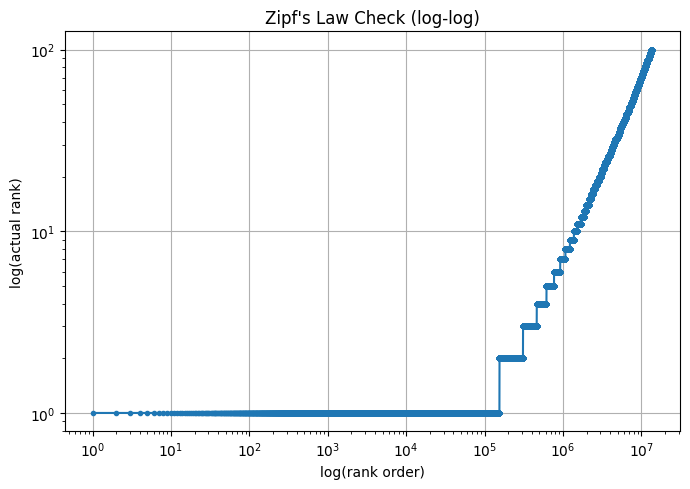

处理后的文件已保存为 amazon_rankings_processed.csv


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# ========= 1. 读取原始数据 =========
file_path = "/blue/qmb6938/_Epoca/Amazon_Rankings/cleaned_auto/amazon_rankings_merged_auto.csv"
df = pd.read_csv(file_path)

print("原始数据列名：", df.columns.tolist())
df.head()


df = df.dropna(subset=["rank"])
df["rank"] = pd.to_numeric(df["rank"], errors="coerce")
df = df.dropna(subset=["rank"])

df_zipf = df.copy()
df_zipf = df_zipf.sort_values("rank")
df_zipf["zipf_rank"] = np.arange(1, len(df_zipf) + 1)

plt.figure(figsize=(7,5))
plt.loglog(df_zipf["zipf_rank"], df_zipf["rank"], marker=".")
plt.xlabel("log(rank order)")
plt.ylabel("log(actual rank)")
plt.title("Zipf's Law Check (log-log)")
plt.grid(True)
plt.tight_layout()
plt.savefig("zipf_law_plot.png", dpi=300)
plt.show()

df["rank_log"] = np.log1p(df["rank"])   # log(1+x)

scaler = StandardScaler()
df["rank_zscore"] = scaler.fit_transform(df[["rank"]])

minmax = MinMaxScaler()
df["rank_minmax"] = minmax.fit_transform(df[["rank"]])

df.to_csv("amazon_rankings_processed.csv", index=False)
print("处理后的文件已保存为 amazon_rankings_processed.csv")

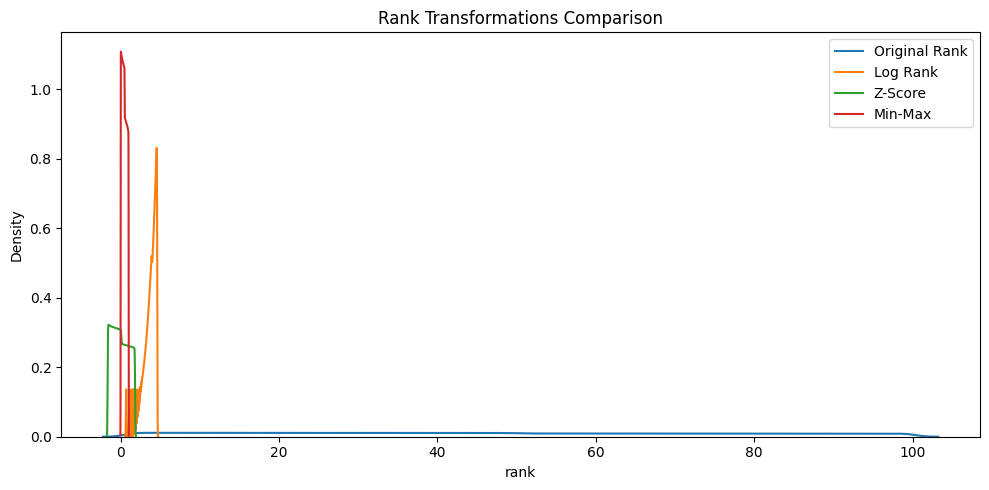

In [6]:
plt.figure(figsize=(10,5))

sns.kdeplot(df["rank"], label="Original Rank")
sns.kdeplot(df["rank_log"], label="Log Rank")
sns.kdeplot(df["rank_zscore"], label="Z-Score")
sns.kdeplot(df["rank_minmax"], label="Min-Max")

plt.title("Rank Transformations Comparison")
plt.legend()
plt.tight_layout()
plt.savefig("rank_transform_comparison.png", dpi=300)
plt.show()


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, MinMaxScaler
import os

# ================================
# 1. Load Data
# ================================
file_path = "/blue/qmb6938/_Epoca/Amazon_Rankings/cleaned_auto/amazon_rankings_merged_auto.csv"
df = pd.read_csv(file_path)

print("Loaded:", df.shape)
print(df.head())

# Ensure Rank exists
if "rank" not in df.columns:
    raise ValueError("Column 'rank' not found in dataset. Check column names:", df.columns)

# Output directory
out_dir = "/blue/qmb6938/_Epoca/Amazon_Rankings/processed_output"
os.makedirs(out_dir, exist_ok=True)

# ================================
# 2. Zipf's Law Distribution
# ================================
df_zipf = df.sort_values("rank")
df_zipf["frequency"] = 1  # each record = 1 count

# Compute rank-frequency cumulative stats
df_zipf['rank_position'] = np.arange(1, len(df_zipf) + 1)

plt.figure(figsize=(8, 6))
plt.loglog(df_zipf["rank_position"], df_zipf["rank"], marker=".", linestyle="none")
plt.xlabel("log(Rank Position)")
plt.ylabel("log(Rank Value)")
plt.title("Zipf's Law - Rank Distribution (log-log scale)")
plt.grid(True)
plt.savefig(f"{out_dir}/zipfs_law.png", dpi=300)
plt.close()

print("Saved Zipf’s Law plot → zipfs_law.png")

# ================================
# 3. Log Transform
# ================================
df["rank_log"] = np.log1p(df["rank"])

plt.figure(figsize=(8, 5))
plt.hist(df["rank_log"], bins=50)
plt.title("Histogram - Log(Rank + 1)")
plt.xlabel("log(rank + 1)")
plt.ylabel("count")
plt.savefig(f"{out_dir}/hist_log.png", dpi=300)
plt.close()

print("Saved log histogram → hist_log.png")

# ================================
# 4. Z-score Standardization
# ================================
scaler = StandardScaler()
df["rank_zscore"] = scaler.fit_transform(df[["rank"]])

plt.figure(figsize=(8, 5))
plt.hist(df["rank_zscore"], bins=50)
plt.title("Histogram - Z-score Standardized Rank")
plt.xlabel("z-score")
plt.ylabel("count")
plt.savefig(f"{out_dir}/hist_zscore.png", dpi=300)
plt.close()

print("Saved z-score histogram → hist_zscore.png")

# ================================
# 5. MinMax Scaling
# ================================
scaler_mm = MinMaxScaler()
df["rank_minmax"] = scaler_mm.fit_transform(df[["rank"]])

plt.figure(figsize=(8, 5))
plt.hist(df["rank_minmax"], bins=50)
plt.title("Histogram - MinMax Scaled Rank")
plt.xlabel("scaled rank (0–1)")
plt.ylabel("count")
plt.savefig(f"{out_dir}/hist_minmax.png", dpi=300)
plt.close()

print("Saved MinMax histogram → hist_minmax.png")

# ================================
# 6. Save processed dataset
# ================================
output_csv = f"{out_dir}/amazon_rankings_processed.csv"
df.to_csv(output_csv, index=False)

print("Processed CSV saved →", output_csv)
print("\n🎉 All Done!")


Loaded: (13697486, 6)
    item_id  rank                category        date  \
0  97578649    70  Cookbooks, Food & Wine  2024-10-26   
1  97578650    44  Cookbooks, Food & Wine  2024-10-26   
2  97578651    65  Cookbooks, Food & Wine  2024-10-26   
3  97578652    64  Cookbooks, Food & Wine  2024-10-26   
4  97578653    74  Cookbooks, Food & Wine  2024-10-26   

                                               title  \
0                                     Magnolia Table   
1                                     Magnolia Table   
2  Magnolia Table, Volume 3: A Collection of Reci...   
3  Magnolia Table, Volume 3: A Collection of Reci...   
4  Magnolia Table, Volume 2: A Collection of Reci...   

                             source_file  
0  Amazon Rankings - 2024-10-(26-31).csv  
1  Amazon Rankings - 2024-10-(26-31).csv  
2  Amazon Rankings - 2024-10-(26-31).csv  
3  Amazon Rankings - 2024-10-(26-31).csv  
4  Amazon Rankings - 2024-10-(26-31).csv  
Saved Zipf’s Law plot → zipfs_law.png
Sa

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, MinMaxScaler
import seaborn as sns
import os

# ===========================================
# 1. 基本路径
# ===========================================
input_path = "/blue/qmb6938/_Epoca/Amazon_Rankings/cleaned_auto/amazon_rankings_merged_auto.csv"
output_dir = "/blue/qmb6938/_Epoca/Amazon_Rankings/cleaned_auto/processed_output_viz"

os.makedirs(output_dir, exist_ok=True)

# ===========================================
# 2. 读取数据
# ===========================================
df = pd.read_csv(input_path)
df = df.dropna(subset=["rank"])
df = df[df["rank"] > 0]

# ===========================================
# 3. 四种变换
# ===========================================

# Log Transform
df["rank_log"] = np.log(df["rank"] + 1)

# Z-score
scaler_z = StandardScaler()
df["rank_zscore"] = scaler_z.fit_transform(df[["rank"]])

# MinMax
scaler_mm = MinMaxScaler()
df["rank_minmax"] = scaler_mm.fit_transform(df[["rank"]])

# ZIPF
df_sorted = df.sort_values("rank")
df_sorted["zipf_idx"] = np.arange(1, len(df_sorted) + 1)

# ===========================================
# ========  A. ECDF (强烈推荐)  =============
# ===========================================
plt.figure(figsize=(7,5))
sns.ecdfplot(df["rank"])
plt.xscale("log")
plt.xlabel("Rank (log scale)")
plt.ylabel("ECDF")
plt.title("ECDF of Rank (Log Scale)")
plt.tight_layout()
plt.savefig(f"{output_dir}/ecdf_rank_logscale.png", dpi=300)
plt.close()

# ===========================================
# ========  B. KDE (密度图)  =================
# ===========================================
plt.figure(figsize=(7,5))
sns.kdeplot(np.log(df["rank"]), fill=True)
plt.xlabel("Log(Rank)")
plt.title("Density of Log(Rank)")
plt.tight_layout()
plt.savefig(f"{output_dir}/kde_log_rank.png", dpi=300)
plt.close()

# ===========================================
# ========  C. Zipf 双对数图  ================
# ===========================================
plt.figure(figsize=(7,5))
plt.loglog(df_sorted["zipf_idx"], df_sorted["rank"], marker='.', linestyle='none')
plt.xlabel("log(rank index)")
plt.ylabel("log(rank)")
plt.title("Zipf Law Check: Rank vs Rank Index")
plt.tight_layout()
plt.savefig(f"{output_dir}/zipf_loglog.png", dpi=300)
plt.close()

# ===========================================
# ========  D. Category Boxplot  ============
# ===========================================
# 只画前 20 个类别 避免太拥挤
top_categories = df["category"].value_counts().head(20).index
df_sub = df[df["category"].isin(top_categories)]

plt.figure(figsize=(10,6))
sns.boxplot(data=df_sub, x="rank_log", y="category", orient="h")
plt.xlabel("Log(Rank)")
plt.ylabel("Category")
plt.title("Category Distribution (Log Rank) – Top 20 Categories")
plt.tight_layout()
plt.savefig(f"{output_dir}/boxplot_category_logrank.png", dpi=300)
plt.close()

# ===========================================
# ========  E. MinMax Rank 曲线（检测趋势）===
# ===========================================
sampled = df.sort_values("date").groupby("title").head(1).sample(800)

plt.figure(figsize=(8,5))
sns.kdeplot(sampled["rank_minmax"], fill=True)
plt.xlabel("MinMax Scaled Rank")
plt.title("Density of MinMax Scaled Rank")
plt.tight_layout()
plt.savefig(f"{output_dir}/kde_minmax_rank.png", dpi=300)
plt.close()

# ===========================================
# 保存新的 CSV
# ===========================================
df.to_csv(f"{output_dir}/amazon_rankings_transformed_v2.csv", index=False)

print("===================================================")
print("All visualizations completed!")
print(f"Files saved in: {output_dir}")
print("Generated plots:")
print(" - ecdf_rank_logscale.png")
print(" - kde_log_rank.png")
print(" - zipf_loglog.png")
print(" - boxplot_category_logrank.png")
print(" - kde_minmax_rank.png")
print(" - amazon_rankings_transformed_v2.csv")
print("===================================================")


All visualizations completed!
Files saved in: /blue/qmb6938/_Epoca/Amazon_Rankings/cleaned_auto/processed_output_viz
Generated plots:
 - ecdf_rank_logscale.png
 - kde_log_rank.png
 - zipf_loglog.png
 - boxplot_category_logrank.png
 - kde_minmax_rank.png
 - amazon_rankings_transformed_v2.csv
